# Scalar-Field Models From an Action

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/dev/examples/03-building-models/scalar_field_models.ipynb)

[`models_from_an_action.ipynb`](models_from_an_action.ipynb) built
models whose Friedmann constraint determines `E(z)` on its own —
`f(T)`, `f(Q)`, General Relativity with a cosmological constant.

Add a dynamical scalar field and that stops being true. The
constraint now involves the field and its velocity, which have their
own equation of motion, so the expansion history has to be
**integrated** rather than solved redshift by redshift. That is what
this notebook is about: quintessence and k-essence, straight from
the action.

It also has a real design decision in it — where the field's initial
conditions go — which is worth understanding before trusting any of
the numbers.

## Setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e ".[theory]"

    # The editable install runs in a subprocess, so this already-running
    # kernel does not see the .pth it writes -- and `import CosmoFit`
    # would resolve to the bare checkout directory instead (same name,
    # and /content is on sys.path). Point sys.path at src/ directly.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e \".[theory]\" from the repository root).")

Not running in Colab -- assuming CosmoFit is already installed (pip install -e ".[theory]" from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy

from CosmoFit import Fitter
from CosmoFit.cosmology.core import ModelConfigurationError
from CosmoFit.cosmology.models import LCDM
from CosmoFit.theory import Action

sympy.init_printing()
plt.rcParams["figure.dpi"] = 110

## 1. The equations, derived

A canonical scalar field has Lagrangian density `X - V(φ)`, where
`X` is the kinetic scalar (`φ̇²/2` on FLRW). Write that, and the
reduction produces both equations it implies.

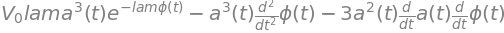

In [3]:
quintessence = Action(
    "R",
    fields={"phi": "X - V0*exp(-lam*phi)"},
    params={
        "V0": {"default": 2.1, "bounds": (0.05, 50.0)},
        "lam": {"default": 0.5, "bounds": (0.0, 1.7), "label": r"$\lambda$"},
    },
    closure="V0",
)

quintessence.field_equations()["phi"]

Divide out the `-a³` and that is
`φ̈ + 3Hφ̇ + dV/dφ = 0` — the Klein–Gordon equation on an expanding
background. Nothing about it was typed in; it came from varying the
action with respect to `φ`.

The Friedmann constraint comes from varying the lapse, as before.

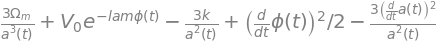

In [4]:
ms, L = quintessence.lagrangian()
from CosmoFit.theory.minisuperspace import friedmann_constraint

sympy.simplify(friedmann_constraint(L, ms) / (-ms.a**3))

## 2. A cosmological constant, written as a field

The cleanest check available: a **constant** potential is a
cosmological constant with extra steps. The field never moves, and
the model must be ΛCDM — reached through an ODE integration and a
shooting solve that ΛCDM has no need of.

In [5]:
ConstantPotential = Action(
    "R",
    fields={"phi": "X - V0"},
    params={"V0": {"default": 2.0}},
    closure="V0",
).build("ConstantPotential")

zz = np.array([0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 100.0, 2000.0])

derived = ConstantPotential(ConstantPotential.PARAMS_CLASS(H0=70.0, Omega_m=0.3))
direct = LCDM(LCDM.PARAMS_CLASS(H0=70.0, Omega_m=0.3))

print(f"V0 from shooting = {derived.closure_value():.10f}")
print(f"3 * Omega_de0    = {3 * direct.Omega_de0:.10f}")
print(f"\nmax relative |E - E_LCDM| = "
      f"{np.max(np.abs(derived.E(zz) / direct.E(zz) - 1)):.2e}")
print(f"w(z)      = {np.round(derived.w(zz), 12)}")
print(f"Omega_de(z) = {np.round(derived.Omega_de(zz), 12)}")

V0 from shooting = 2.1000000000
3 * Omega_de0    = 2.1000000000
max relative |E - E_LCDM| = 4.96e-12
w(z)      = [-1. -1. -1. -1. -1. -1. -1. -1.]
Omega_de(z) = [0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7]


`w = -1` and `Omega_de` constant at every redshift, as a
cosmological constant requires.

Note that `V0` was not solved from a formula. The field's state is
given *early* and the history integrated forwards, so `E(0) = 1` is
a **shooting** condition — several integrations, each adjusting `V0`
until `H(0)` lands on 1.

## 3. Why the initial conditions go early

This is the design decision, and the first version of this code got
it wrong.

Setting the field's state at `a = 1` would be far more convenient:
`H = 1` holds there by the definition of `H0`, so `E(0) = 1` becomes
algebraic and no shooting is needed at all.

It is also **wrong**. Integrating backwards from a field at rest
today, the Hubble friction `-3Hφ̇` that damps the field forwards in
time becomes *anti*-friction. The generic past solution is
kinetic-dominated, `ρ_φ` grows as `a⁻⁶`, and for exponential
quintessence normalized to today's dark-energy density that gives

> **`E(2.5) = 9.3`, where ΛCDM gives 3.7.**

Nothing about the calculation fails. It is the correct past of those
initial conditions, and those initial conditions are not a universe.

So the state is given where a quintessence model actually gives it —
early (`z_init`, default 3000) and typically frozen (`dphi_i = 0`,
which is what Hubble friction does to a field at early times) — and
the system is integrated **forwards**, which is also the numerically
stable direction.

Each field therefore adds two parameters, `<name>_i` and
`d<name>_i`.

In [6]:
print("EXTRA_PARAMS:", sorted(ConstantPotential.EXTRA_PARAMS))
print("\n(V0 is absent: it is solved for by the closure condition, not fit.)")

# There is no history before the field's state is given.
model = quintessence.build("ExponentialQuintessence")
m = model(model.PARAMS_CLASS(H0=70.0, Omega_m=0.3, lam=0.5))
print(f"\nE(2500) = {float(m.E(2500.0)):.4f}")
try:
    m.E(5000.0)
except ModelConfigurationError as exc:
    print(f"\nE(5000):\n    {exc}")

EXTRA_PARAMS: ['dphi_i', 'phi_i']
(V0 is absent: it is solved for by the closure condition, not fit.)


E(2500) = 68506.4030
E(5000):
    E(z) was asked for at z = 5000, beyond this model's initial redshift z_init = 3000. There is no history before the field's state is given, and extrapolating one would be inventing the early universe rather than solving for it. Build the model with a larger Action(z_init=...).


## 4. What the field does

`lam = 0` is a constant potential, i.e. ΛCDM. Turning `lam` up makes
the potential steeper, the field rolls, and `w` lifts off `-1`.

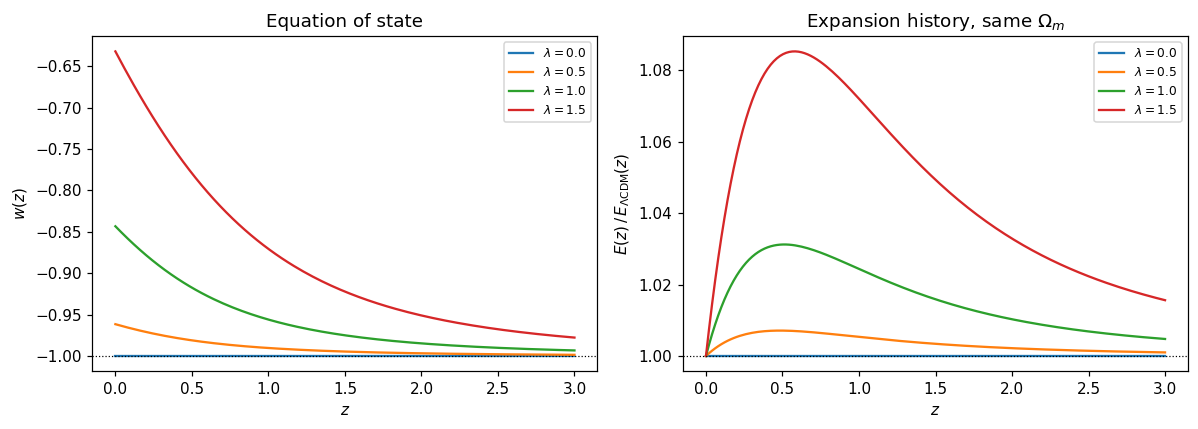

In [7]:
zplot = np.linspace(0.0, 3.0, 150)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for lam in (0.0, 0.5, 1.0, 1.5):
    mm = model(model.PARAMS_CLASS(H0=70.0, Omega_m=0.3, lam=lam))
    axes[0].plot(zplot, mm.w(zplot), label=rf"$\lambda = {lam:.1f}$")
    axes[1].plot(zplot, mm.E(zplot) / direct.E(zplot), label=rf"$\lambda = {lam:.1f}$")

axes[0].axhline(-1.0, color="k", lw=0.8, ls=":")
axes[0].set_xlabel("$z$"); axes[0].set_ylabel("$w(z)$")
axes[0].set_title("Equation of state")
axes[1].axhline(1.0, color="k", lw=0.8, ls=":")
axes[1].set_xlabel("$z$")
axes[1].set_ylabel(r"$E(z)\,/\,E_{\Lambda\rm CDM}(z)$")
axes[1].set_title(r"Expansion history, same $\Omega_m$")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()

`w(z)` is read off the field's own Lagrangian — the pressure of any
`L(X, φ)` is `L` itself and the density is `2X L_X - L`. The
alternative, subtracting the fluids out of `E(z)²`, cancels
catastrophically once matter dominates: at `z = 2000` it is
2.4e9 minus 2.4e9 to get 0.7, and returns `w = -5.8` where the answer
is `-1`.

## 5. Validation: the Copeland–Liddle–Wands attractors

Copeland, Liddle & Wands (1998) solved the exponential potential
exactly. Its late-time attractors depend on the slope **alone** —
there is nothing to tune, which is what makes them a real test. On a
matter background there are two, selected by `λ²` against 3:

| | reached when | `w` | `Ω_φ` |
|---|---|---|---|
| field-dominated | `λ² < 3` | `-1 + λ²/3` | 1 |
| scaling | `λ² > 3` | `0` (matter-like) | `3/λ²` |

The scaling fraction is the sharp one: a pure prediction of the
slope, with no freedom left anywhere in the model.

We check both by looking deep into the future, at `a = 3×10⁴`.

In [8]:
a_late = 3.0e4
z_late = 1.0 / a_late - 1.0

print(f"{'lam':>5s} {'lam^2':>6s} {'branch':>14s} "
      f"{'w':>10s} {'predicted':>10s} {'Om_phi':>9s} {'predicted':>10s}")
for lam in (0.5, 1.0, 1.5, 1.9, 2.0):
    mm = model(model.PARAMS_CLASS(H0=70.0, Omega_m=0.3, lam=lam))
    w = float(mm.w(z_late))
    fraction = float(mm.Omega_de(z_late)) / float(mm.E(z_late)) ** 2
    if lam**2 < 3.0:
        branch, w_pred, f_pred = "field-dominated", -1 + lam**2 / 3, 1.0
    else:
        branch, w_pred, f_pred = "scaling", 0.0, 3.0 / lam**2
    print(f"{lam:5.2f} {lam**2:6.2f} {branch:>14s} "
          f"{w:10.6f} {w_pred:10.6f} {fraction:9.5f} {f_pred:10.5f}")

  lam  lam^2         branch          w  predicted    Om_phi  predicted
 0.50   0.25 field-dominated  -0.916667  -0.916667   1.00000    1.00000


 1.00   1.00 field-dominated  -0.666667  -0.666667   1.00000    1.00000
 1.50   2.25 field-dominated  -0.250074  -0.250000   0.99994    1.00000


 1.90   3.61        scaling  -0.000035   0.000000   0.83097    0.83102
 2.00   4.00        scaling   0.000035   0.000000   0.75006    0.75000


### The wall at steep potentials

Past `λ² > 3` the scaling attractor pins the dark-energy fraction at
`3/λ²`. Ask such a model for more than that and there is no solution
at all — `H(0)` saturates below 1, and no potential scale reaches it.

`λ = 2.2` gives `3/λ² = 0.62`, short of the 0.7 that
`Omega_m = 0.3` needs.

In [9]:
steep = Action(
    "R",
    fields={"phi": "X - V0*exp(-lam*phi)"},
    params={"V0": {"default": 2.1}, "lam": {"default": 0.5}},
    closure="V0",
).build("SteepQuintessence")

try:
    steep(steep.PARAMS_CLASS(H0=70.0, Omega_m=0.3, lam=2.2)).E(0.0)
except RuntimeError as exc:
    print(f"{type(exc).__name__}:\n    {exc}")

RuntimeError:
    Could not solve E(0) = 1 for 'V0' at these parameter values: H(0) came out 0.881035 rather than 1. The requested expansion history may not be reachable from this model -- narrow the prior bounds, or move the parameter's default nearer the intended branch.


That is a statement about exponential quintessence, and it arrives
as one rather than as a stalled integrator. It is also why steep
potentials are ruled out: a model that cannot make the dark-energy
fraction large enough cannot accelerate.

## 6. Fitting it

Integrating a coupled system with a shooting closure costs about
**37 ms per parameter set**, against ~150 µs for a closed-form
model. So the chain here is deliberately shorter than elsewhere in
these examples, and the profile likelihood does more of the work.

`λ` also sits against a hard boundary at 0 (ΛCDM), which is exactly
the situation where a marginal posterior is easy to misread — so the
profile is the more honest picture of what the data say.

In [10]:
fit = Fitter(
    model=model,
    datasets=["cc", "desi"],
    free_params=["H0", "Omega_m", "lam", "rd"],
    initial={"H0": 70.0, "Omega_m": 0.3, "lam": 0.3, "rd": 147.0},
)

best = fit.best_fit(restarts=2, seed=0)
for name, value in zip(fit.free_params, best.x):
    print(f"  {name:8s} = {value: .4f}")
print(f"\n  chi2 = {best.fun:.3f}")

  H0       =  69.2970
  Omega_m  =  0.2970
  lam      =  0.6217
  rd       =  145.5627
  chi2 = 25.547


In [11]:
reference = Fitter(
    model=LCDM,
    datasets=["cc", "desi"],
    free_params=["H0", "Omega_m", "rd"],
    initial={"H0": 70.0, "Omega_m": 0.3, "rd": 147.0},
).best_fit(restarts=2, seed=0)

print(f"LCDM         chi2 = {reference.fun:.3f}  (3 parameters)")
print(f"quintessence chi2 = {best.fun:.3f}  (4 parameters)")
print(f"\ndelta chi2 = {reference.fun - best.fun:+.3f} for one extra parameter")

LCDM         chi2 = 25.646  (3 parameters)
quintessence chi2 = 25.547  (4 parameters)
delta chi2 = +0.099 for one extra parameter


  lam = 0  chi2 = 25.6464


  lam = 0.133333  chi2 = 25.6378


  lam = 0.266667  chi2 = 25.6142


  lam = 0.4  chi2 = 25.5822


  lam = 0.533333  chi2 = 25.5548


...

  lam = 1.06667  chi2 = 26.0137


  lam = 1.2  chi2 = 26.5289


  lam = 1.33333  chi2 = 27.3881


  lam = 1.46667  chi2 = 28.7857


  lam = 1.6  chi2 = 31.0075


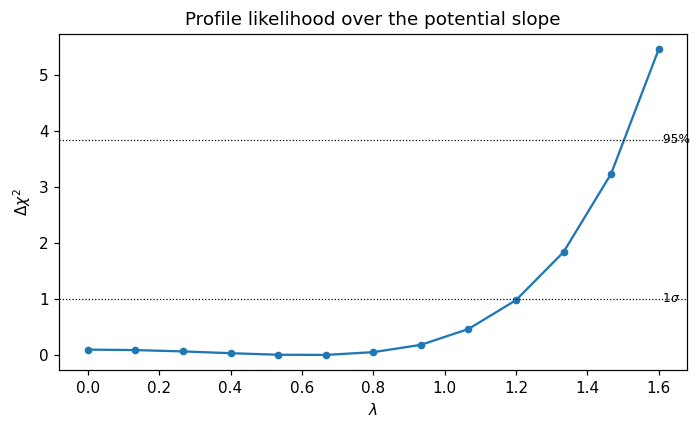

In [12]:
lam_grid = np.linspace(0.0, 1.6, 13)
profile = fit.profile("lam", lam_grid, seed=0, progress=True)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(profile["values"], profile["delta_chi2"], "o-", lw=1.5, ms=4)
for level, label in [(1.0, r"$1\sigma$"), (3.84, "95%")]:
    ax.axhline(level, color="k", lw=0.8, ls=":")
    ax.text(lam_grid[-1], level, f" {label}", va="center", fontsize=8)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\Delta\chi^2$")
ax.set_title(r"Profile likelihood over the potential slope")
fig.tight_layout()

The minimum sits near `λ = 0`, and the curve is flat over a wide
range — CC + DESI alone barely care. That is the published picture
for quintessence from background data.

A short chain, to see the parameter correlations.

In [13]:
fit.run_mcmc(nwalkers=20, nsteps=1200, burnin=300, seed=0, progress=True)
print(fit.result)

  0%|          | 0/1200 [00:00<?, ?it/s]


  0%|          | 1/1200 [00:00<18:28,  1.08it/s]


  0%|          | 2/1200 [00:01<18:24,  1.08it/s]


  0%|          | 3/1200 [00:02<19:25,  1.03it/s]


  0%|          | 4/1200 [00:03<19:16,  1.03it/s]


...

100%|█████████▉| 1199/1200 [23:42<00:01,  1.14s/it]


100%|██████████| 1200/1200 [23:43<00:00,  1.15s/it]


100%|██████████| 1200/1200 [23:43<00:00,  1.19s/it]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 18;
tau: [48.46706437 40.34542344 46.46055831 44.15380882]


FitResult(model=ExponentialQuintessence, datasets=['cc', 'desi'], free_params=['H0', 'Omega_m', 'lam', 'rd'])
  BestFitResult(H0=69.297, Omega_m=0.29703, lam=0.621654, rd=145.563, chi2=25.5472, AIC=33.55, BIC=40.68)
  MCMCResult(20 walkers x 1200 steps, burnin=300, NOT converged, acceptance=0.54)
  H0 = 68.6979 (+3.5/-3.6)
  Omega_m = 0.299611 (+0.015/-0.016)
  lam = 0.636737 (+0.47/-0.43)
  rd = 145.903 (+6.9/-6.2)


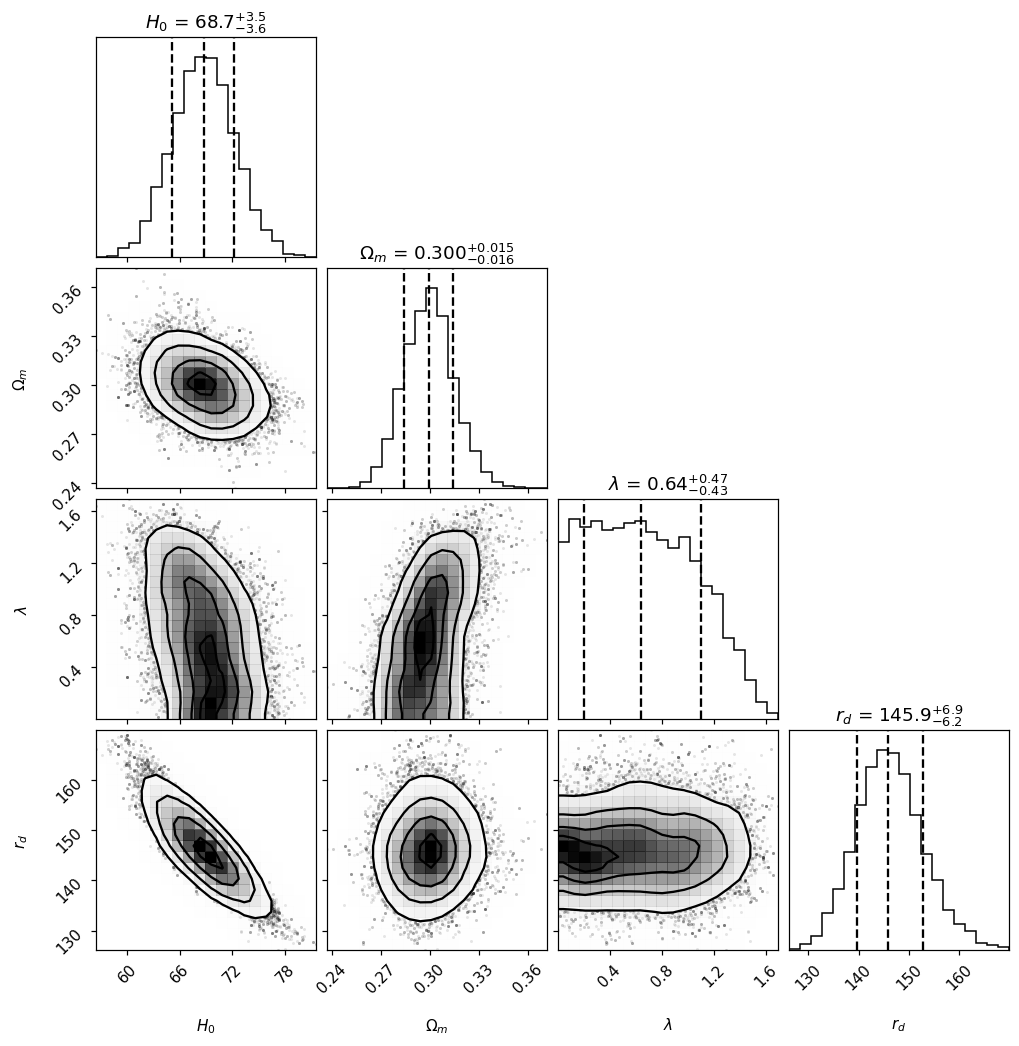

In [14]:
fit.plots.corner();

## 7. Scalar-tensor gravity

Everything so far has been a field sitting *on top of* General
Relativity. Let the gravitational sector see the field and it
becomes a different theory: the field sets the **strength** of
gravity.

$$S = \tfrac{1}{2}\int\sqrt{-g}\,F(\phi)R \;-\; \tfrac{1}{2}(\partial\phi)^2 - V(\phi)$$

A field's name is in scope in the `gravity` expression, which is
how you say so. The Friedmann equation gains a term:

$$3FH^2 + 3H\dot{F} = \rho .$$

In [15]:
def scalar_tensor(xi, growth="gr", z_init=20000.0):
    return Action(
        "(1 + xi*phi**2)*R",              # F(phi) R, not R + phi
        fields={"phi": "X - V0"},
        params={"xi": {"default": xi, "bounds": (-0.5, 0.5)},
                "V0": {"default": 2.1, "bounds": (0.05, 20.0)}},
        closure="V0",
        growth=growth,
        z_init=z_init,
    ).build("ScalarTensor")


ST = scalar_tensor(0.05)
print("parameters:", sorted(ST.EXTRA_PARAMS))

st = ST(ST.PARAMS_CLASS(H0=70.0, Omega_m=0.3, xi=0.05, phi_i=1.0, dphi_i=0.0))
print(f"\nV0 from shooting = {st.closure_value():.6f}")
print(f"E(0) = {float(st.E(0.0)):.12f}")

parameters: ['dphi_i', 'phi_i', 'xi']
V0 from shooting = 3.213922
E(0) = 0.999999999998


In [16]:
zst = np.array([0.0, 0.5, 1.0, 2.0, 5.0])

print(f"{'xi':>7s} {'max|E/E_LCDM-1|':>17s} {'drift':>10s}")
for xi in (0.0, 0.05, -0.05):
    m = scalar_tensor(xi)(scalar_tensor(xi).PARAMS_CLASS(
        H0=70.0, Omega_m=0.3, xi=xi, phi_i=1.0, dphi_i=0.0))
    print(f"{xi:+7.2f} {np.max(np.abs(m.E(zst)/direct.E(zst) - 1)):17.3e} "
          f"{m.history(zst).drift:10.2e}")

print("\nxi = 0 is General Relativity, and it comes back exactly.")

     xi   max|E/E_LCDM-1|      drift


  +0.00         5.632e-12   2.19e-11


  +0.05         9.704e-02   1.10e-12


  -0.05         4.222e-03   5.60e-13
xi = 0 is General Relativity, and it comes back exactly.


### It also changes how structure grows, and that is easy to miss

In scalar-tensor gravity $G_{\rm eff}/G_N$ is neither 1 nor
constant — it **moves as the field rolls**. A background action
does not by itself determine that, so `mu` stays at 1 unless asked,
exactly as for `f(T)`/`f(Q)`.

Left at the default, fitting growth data would give General
Relativity's growth attached to a modified background: a finite
χ², a plausible posterior, and no way to tell. So the library
warns.

In [17]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    Fitter(model=scalar_tensor(0.05, growth="gr"),
           datasets=["fsigma8"],
           free_params=["H0", "Omega_m", "sigma8"],
           initial={"H0": 70.0, "Omega_m": 0.3, "sigma8": 0.81,
                    "xi": 0.05, "phi_i": 1.0})

for warning in caught:
    print(warning.message)

ScalarTensor couples its field to the curvature -- scalar-tensor gravity -- but reports mu = 1, so ['fsigma8'] would be fit with General Relativity's growth on top of a modified background.
In this theory G_eff/G_N is neither 1 nor constant: it moves as the field rolls. Rebuild the action with growth='quasi_static' for the sub-horizon result, or drop the growth data.


`growth="quasi_static"` gives the sub-horizon result of Boisseau,
Esposito-Farèse, Polarski & Starobinsky (2000),

$$\mu = \frac{2F + 4F_{,\phi}^2}{F\,(2F + 3F_{,\phi}^2)},$$

evaluated on the field's own solution. `F = 1` with a constant
coupling gives exactly 1 — the normalization it has to satisfy.

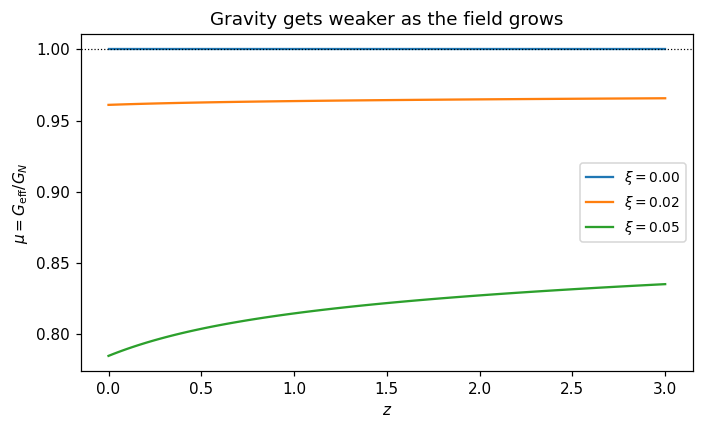

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 4))
zmu = np.linspace(0.0, 3.0, 120)

for xi in (0.0, 0.02, 0.05):
    m = scalar_tensor(xi, growth="quasi_static")
    c = m(m.PARAMS_CLASS(H0=70.0, Omega_m=0.3, xi=xi,
                         phi_i=1.0, dphi_i=0.0))
    ax.plot(zmu, c.mu(1.0 / (1.0 + zmu)), label=rf"$\xi = {xi:.2f}$")

ax.axhline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel("$z$")
ax.set_ylabel(r"$\mu = G_{\rm eff}/G_N$")
ax.set_title("Gravity gets weaker as the field grows")
ax.legend(fontsize=9)
fig.tight_layout()

### One practical trap

A field's history starts at `z_init`, default **3000**. The growth
ODE starts at **z = 9999**. So fitting `fsigma8` needs a model
built with a larger `z_init` — which is why every scalar-tensor
model above used `z_init=20000`.

Getting that wrong used to return `chi2 = inf` at every parameter
value: a fit that ran to completion having learned nothing and
saying nothing. It is now an error that names the fix, because it
is a property of how the model was *built* rather than of the
point being evaluated.

In [19]:
narrow = Action(
    "R",
    fields={"phi": "X - V0"},
    params={"V0": {"default": 2.1}},
    closure="V0",
    z_init=3000.0,           # too shallow for the growth ODE
).build("TooShallow")

fit = Fitter(model=narrow, datasets=["fsigma8"],
             free_params=["H0", "Omega_m", "sigma8"],
             initial={"H0": 70.0, "Omega_m": 0.3, "sigma8": 0.81})

try:
    fit.chi2()
except Exception as exc:
    print(f"{type(exc).__name__}:\n{exc}")

ModelConfigurationError:
E(z) was asked for at z = 9999, beyond this model's initial redshift z_init = 3000. There is no history before the field's state is given, and extrapolating one would be inventing the early universe rather than solving for it. Build the model with a larger Action(z_init=...).


## 8. Beyond quintessence

`fields=` takes any `L(X, φ)`, so k-essence is the same call with a
different string — the reduction, the equations of motion and the
integration all follow from whatever is written there.

```python
Action(
    "R",
    fields={"phi": "X + X**2/M4 - V0*exp(-lam*phi)"},   # k-essence
    params={...},
    closure="V0",
)
```

**How well is it solved?** The Friedmann constraint is imposed once,
in the initial conditions, and never again — the history runs off the
equations of motion, for which the constraint is a first integral. So
how far it drifts is an *independent* measure of the integration
error rather than a restatement of the tolerance.

In [20]:
m = model(model.PARAMS_CLASS(H0=70.0, Omega_m=0.3, lam=1.0))
history = m.history(np.linspace(0.0, 2.5, 40))
print(f"maximum relative drift of the Friedmann constraint: {history.drift:.2e}")

maximum relative drift of the Friedmann constraint: 1.69e-13


## Where to go next

- [`models_from_an_action.ipynb`](models_from_an_action.ipynb) —
  actions without fields, and what the reduction refuses to do.
- [`../04-inference/profile_likelihood_and_fisher.ipynb`](../04-inference/profile_likelihood_and_fisher.ipynb)
  — profile likelihoods in general, including why a boundary breaks
  the usual Δχ² reading.
- [`../02-models/holographic_family.ipynb`](../02-models/holographic_family.ipynb)
  — dark-energy models that also need an ODE, written by hand.